# PaySim Fraud Detection — End-to-End Data Science Workflow

## Problem Overview
Fraud detection is a critical problem in digital payments because fraudulent transactions create direct financial losses and reduce trust in the platform. The goal of this project is to build machine learning models that can accurately identify fraudulent mobile money transactions.

## Dataset
This project uses the **PaySim synthetic mobile money transaction dataset**, a widely used transaction-level dataset for fraud detection experiments. It contains transaction attributes such as transaction type, amount, sender and receiver balances before and after the transaction, and fraud labels.

The target variable is **`isFraud`**, a binary indicator where:
- `0` = legitimate transaction
- `1` = fraudulent transaction

## Objective
This notebook follows the full data science workflow required in the assignment:

1. Understand and visualize the dataset
2. Build and compare multiple predictive models
3. Explain the best model using SHAP
4. Save trained assets for deployment in Streamlit

Because fraud is a **highly imbalanced classification problem**, metrics such as **Recall, F1 score, ROC-AUC, and PR-AUC** are more informative than accuracy alone.


In [2]:
# ============================================================
# MSIS 522 HW1 — PaySim Fraud Dataset
# File: data.csv
# ============================================================

import pandas as pd

# ----------------------------
# 1) Load the dataset
# ----------------------------
FILE_PATH = "data.csv"
df = pd.read_csv(FILE_PATH)

print("✅ Loaded dataset:", FILE_PATH)
print("Shape (rows, cols):", df.shape)
display(df.head(5))
print("\nColumn dtypes:")
display(df.dtypes)

# ----------------------------
# 2) Confirm expected columns
# ----------------------------
expected_cols = [
    "step", "type", "amount", "nameOrig",
    "oldbalanceOrg", "newbalanceOrig",
    "nameDest", "oldbalanceDest", "newbalanceDest",
    "isFraud", "isFlaggedFraud"
]

missing_expected = [c for c in expected_cols if c not in df.columns]
if missing_expected:
    print("\n⚠️ These expected PaySim columns were NOT found (check your CSV):")
    print(missing_expected)
else:
    print("\n✅ All expected PaySim columns found.")

# ----------------------------
# 3) Basic missing values check
# ----------------------------
print("\nMissing value % (top 10 columns):")
display((df.isna().mean() * 100).sort_values(ascending=False).head(10))

# ----------------------------
# 4) Target distribution (fraud rate)
# ----------------------------
print("\nTarget distribution (counts):")
display(df["isFraud"].value_counts())

print("\nTarget distribution (fraud rate):")
display(df["isFraud"].value_counts(normalize=True))

# ----------------------------
# 5) Sample for speed
# ----------------------------
# Full PaySim is ~6.3M rows. Sampling keeps training + plots fast.
SAMPLE_N = 800_000

if len(df) > SAMPLE_N:
    df = df.sample(SAMPLE_N, random_state=42).reset_index(drop=True)
    print(f"\n✅ Sampled to {SAMPLE_N:,} rows for faster modeling/EDA.")
else:
    print(f"\n✅ Dataset has <= {SAMPLE_N:,} rows; no sampling needed.")

print("Sampled shape:", df.shape)

# ----------------------------
# 6) Sanity check: Fraud rate by transaction type
# ----------------------------
# EDA insight: in PaySim, fraud usually concentrates in certain types (often TRANSFER/CASH_OUT).
fraud_by_type = pd.crosstab(df["type"], df["isFraud"], normalize="index")
fraud_by_type.columns = ["NonFraud_rate", "Fraud_rate"]
fraud_by_type = fraud_by_type.sort_values("Fraud_rate", ascending=False)

print("\nFraud rate by transaction type:")
display(fraud_by_type)

# ----------------------------
# 7) Creating a few helpful engineered features
# ----------------------------
df["orig_balance_delta"] = df["oldbalanceOrg"] - df["newbalanceOrig"]
df["dest_balance_delta"] = df["newbalanceDest"] - df["oldbalanceDest"]

print("\n✅ Added engineered features: orig_balance_delta, dest_balance_delta")
display(df[["oldbalanceOrg", "newbalanceOrig", "orig_balance_delta",
            "oldbalanceDest", "newbalanceDest", "dest_balance_delta"]].head(5))

# ----------------------------
# 8) Save the sampled dataframe
# ----------------------------

SAMPLED_OUT = "data_sampled.csv"
df.to_csv(SAMPLED_OUT, index=False)
print(f"\n✅ Saved sampled dataset to: {SAMPLED_OUT}")


✅ Loaded dataset: data.csv
Shape (rows, cols): (6362620, 11)


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0



Column dtypes:


,0
step,int64
type,object
amount,float64
nameOrig,object
oldbalanceOrg,float64
newbalanceOrig,float64
nameDest,object
oldbalanceDest,float64
newbalanceDest,float64
isFraud,int64



✅ All expected PaySim columns found.

Missing value % (top 10 columns):


...


✅ Sampled to 800,000 rows for faster modeling/EDA.
Sampled shape: (800000, 11)

Fraud rate by transaction type:


,NonFraud_rate,Fraud_rate
type,,
TRANSFER,0.992365,0.007635
CASH_OUT,0.998228,0.001772
CASH_IN,1.000000,0.000000
DEBIT,1.000000,0.000000
PAYMENT,1.000000,0.000000



✅ Added engineered features: orig_balance_delta, dest_balance_delta


,oldbalanceOrg,newbalanceOrig,orig_balance_delta,oldbalanceDest,newbalanceDest,dest_balance_delta
0,20866.00,351084.42,-330218.42,452419.57,122201.15,-330218.42
1,30370.00,18722.92,11647.08,0.00,0.00,0.00
2,106589.00,258853.21,-152264.21,201303.01,49038.80,-152264.21
3,0.00,0.00,0.00,3198359.45,4750120.08,1551760.63
4,2921331.58,2999503.88,-78172.30,415821.90,337649.60,-78172.30



✅ Saved sampled dataset to: data_sampled.csv


In [3]:
# =========================
# Part 1.1 — Dataset Intro
# =========================
import numpy as np

target = "isFraud"

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
print("\nTarget:", target)
print("Fraud rate:", df[target].mean())

# Feature type summary
num_cols = df.select_dtypes(include=np.number).columns.tolist()
cat_cols = df.select_dtypes(exclude=np.number).columns.tolist()

print("\nNumerical columns:", len(num_cols))
print("Categorical columns:", len(cat_cols))
print("\nCategorical columns:", cat_cols)


Rows: 800000
Columns: 13

Target: isFraud
Fraud rate: 0.0012625

Numerical columns: 10
Categorical columns: 3

Categorical columns: ['type', 'nameOrig', 'nameDest']


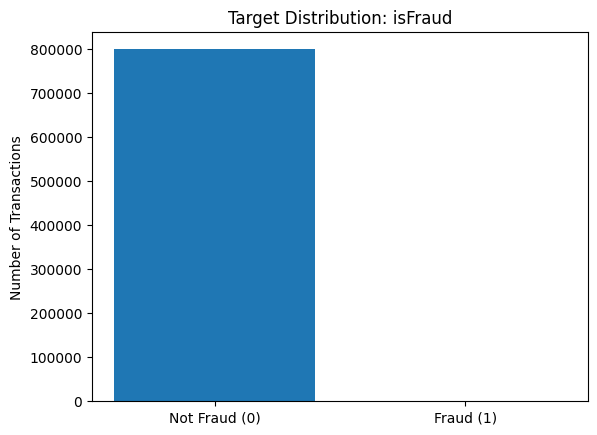

Class counts:
 isFraud
0    798990
1      1010
Name: count, dtype: int64
Fraud rate: 0.0012625


In [4]:
# =========================
# Part 1.2 — Target Plot
# =========================
import matplotlib.pyplot as plt

counts = df["isFraud"].value_counts().sort_index()

plt.figure()
plt.bar(["Not Fraud (0)", "Fraud (1)"], counts.values)
plt.title("Target Distribution: isFraud")
plt.ylabel("Number of Transactions")
plt.show()

print("Class counts:\n", counts)
print("Fraud rate:", df["isFraud"].mean())


## Target Distribution Analysis

The target distribution shows that fraudulent transactions make up only a very small share of all transactions. This confirms that fraud detection is an **extremely imbalanced classification problem**.

For this reason, accuracy is not enough to judge model quality. A model can achieve very high accuracy by predicting almost every transaction as non-fraud. In this project, greater emphasis is placed on **Recall**, **F1 score**, **ROC-AUC**, and **PR-AUC**, which better reflect the model's ability to identify rare fraud cases.


## Part 1.3 — Feature Distributions and Relationships

The following visualizations focus on patterns that help distinguish fraudulent and legitimate transactions. Together they show how transaction type, amount, balance changes, and time behavior relate to fraud.


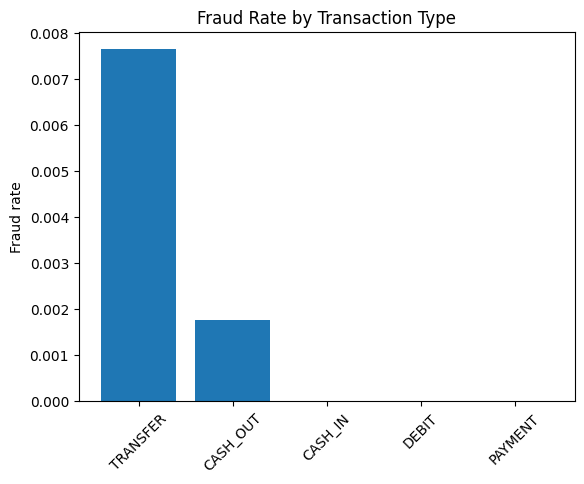

,1
type,
TRANSFER,0.007635
CASH_OUT,0.001772
CASH_IN,0.000000
DEBIT,0.000000
PAYMENT,0.000000


In [5]:
import pandas as pd
import matplotlib.pyplot as plt

type_fraud = pd.crosstab(df["type"], df["isFraud"], normalize="index")[1].sort_values(ascending=False)

plt.figure()
plt.bar(type_fraud.index.astype(str), type_fraud.values)
plt.title("Fraud Rate by Transaction Type")
plt.ylabel("Fraud rate")
plt.xticks(rotation=45)
plt.show()

type_fraud


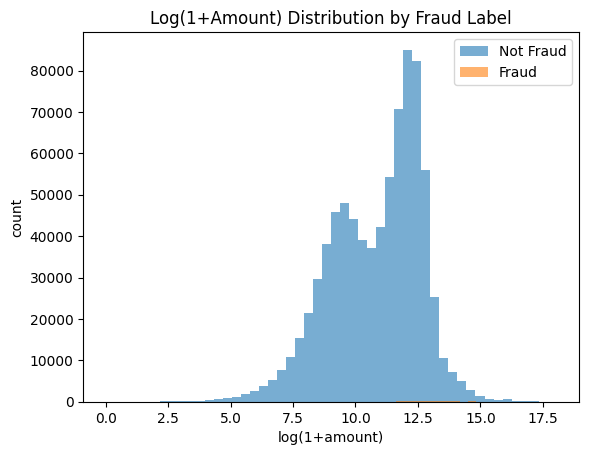

In [6]:
import numpy as np

df_plot = df.copy()
df_plot["log_amount"] = np.log1p(df_plot["amount"])

plt.figure()
plt.hist(df_plot[df_plot["isFraud"]==0]["log_amount"], bins=50, alpha=0.6, label="Not Fraud")
plt.hist(df_plot[df_plot["isFraud"]==1]["log_amount"], bins=50, alpha=0.6, label="Fraud")
plt.title("Log(1+Amount) Distribution by Fraud Label")
plt.xlabel("log(1+amount)")
plt.ylabel("count")
plt.legend()
plt.show()


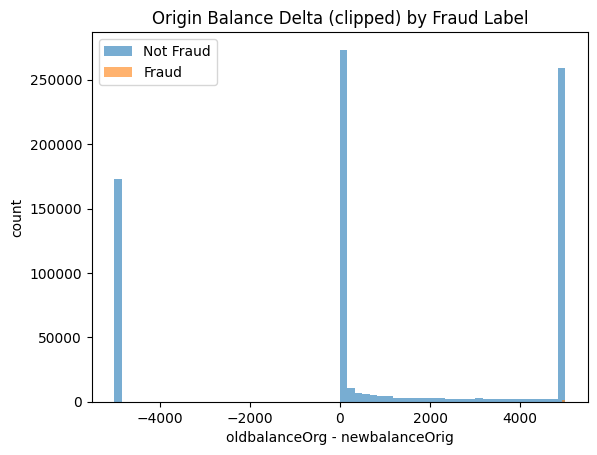

In [7]:
plt.figure()
plt.hist(np.clip(df[df["isFraud"]==0]["orig_balance_delta"], -5000, 5000), bins=60, alpha=0.6, label="Not Fraud")
plt.hist(np.clip(df[df["isFraud"]==1]["orig_balance_delta"], -5000, 5000), bins=60, alpha=0.6, label="Fraud")
plt.title("Origin Balance Delta (clipped) by Fraud Label")
plt.xlabel("oldbalanceOrg - newbalanceOrig")
plt.ylabel("count")
plt.legend()
plt.show()


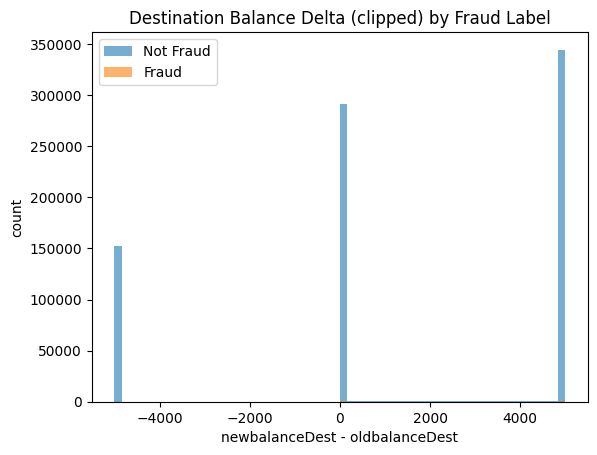

In [8]:
plt.figure()
plt.hist(np.clip(df[df["isFraud"]==0]["dest_balance_delta"], -5000, 5000), bins=60, alpha=0.6, label="Not Fraud")
plt.hist(np.clip(df[df["isFraud"]==1]["dest_balance_delta"], -5000, 5000), bins=60, alpha=0.6, label="Fraud")
plt.title("Destination Balance Delta (clipped) by Fraud Label")
plt.xlabel("newbalanceDest - oldbalanceDest")
plt.ylabel("count")
plt.legend()
plt.show()


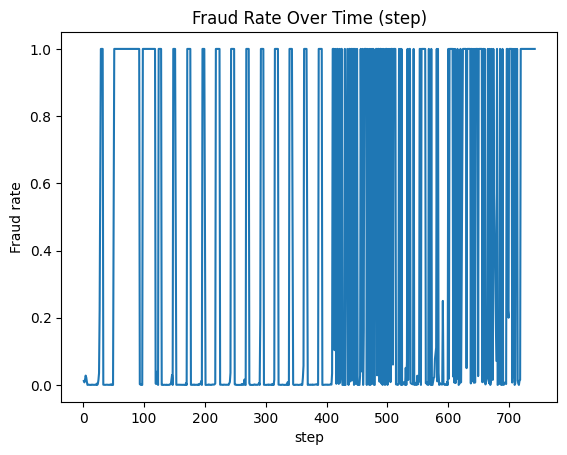

In [9]:
fraud_by_step = df.groupby("step")["isFraud"].mean()

plt.figure()
plt.plot(fraud_by_step.index, fraud_by_step.values)
plt.title("Fraud Rate Over Time (step)")
plt.xlabel("step")
plt.ylabel("Fraud rate")
plt.show()


## Feature Visualization Insights

The descriptive analytics point to several useful fraud signals:

1. **Fraud rate by transaction type:** Fraud is concentrated in specific transaction categories rather than being evenly distributed across all transaction types. This indicates that transaction type should be an important predictive feature.

2. **Transaction amount distribution:** Fraudulent transactions tend to appear in different parts of the amount distribution than legitimate transactions, suggesting that unusual transfer sizes may be informative.

3. **Origin and destination balance deltas:** The engineered balance-change features reveal abnormal account movement patterns in fraud cases. These balance shifts are likely to be among the strongest model inputs.

4. **Fraud over time (`step`):** Fraud risk may vary over time rather than remaining constant, which suggests that temporal transaction context can add predictive value.


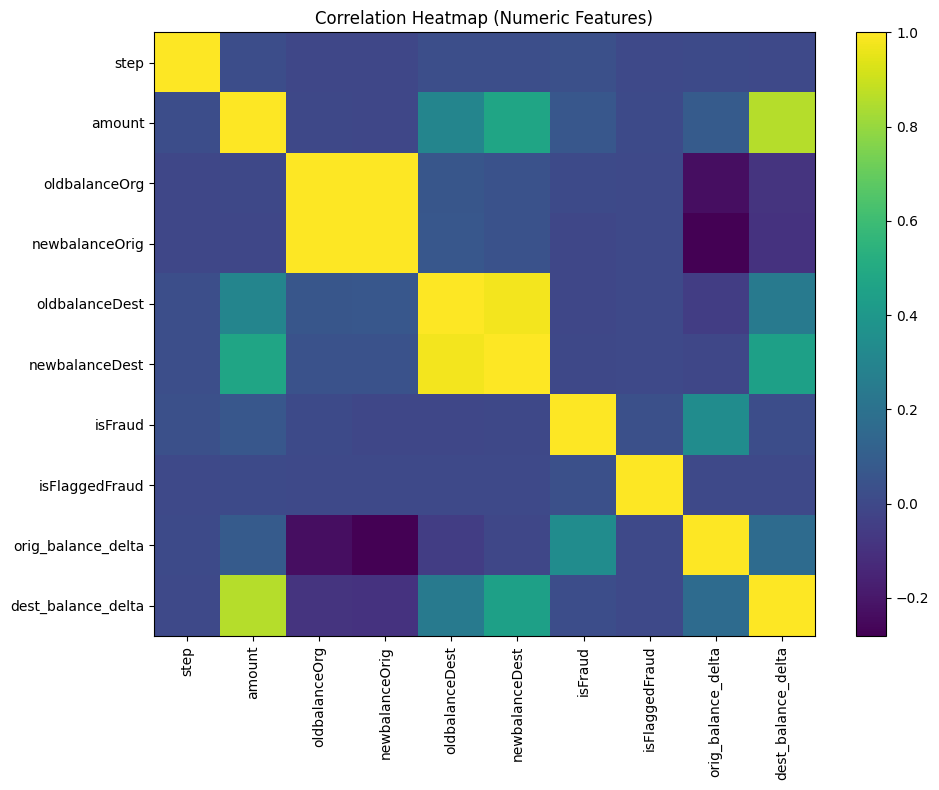

Top correlations with isFraud:


,isFraud
isFraud,1.000000
orig_balance_delta,0.341619
amount,0.066562
isFlaggedFraud,0.031446
step,0.031297
dest_balance_delta,0.022974
oldbalanceOrg,0.007518
newbalanceDest,-0.001107
oldbalanceDest,-0.006764
newbalanceOrig,-0.009059


,isFraud
isFraud,1.000000
orig_balance_delta,0.341619
amount,0.066562
isFlaggedFraud,0.031446
step,0.031297
dest_balance_delta,0.022974
oldbalanceOrg,0.007518
newbalanceDest,-0.001107
oldbalanceDest,-0.006764
newbalanceOrig,-0.009059


In [10]:
# =========================
# Part 1.4 — Correlation
# =========================
import numpy as np
import matplotlib.pyplot as plt

numeric_df = df.select_dtypes(include=np.number).copy()
corr = numeric_df.corr()

plt.figure(figsize=(10, 8))
plt.imshow(corr, aspect="auto")
plt.colorbar()
plt.title("Correlation Heatmap (Numeric Features)")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.tight_layout()
plt.show()

# Show strongest correlations with target
target_corr = corr["isFraud"].sort_values(ascending=False)
print("Top correlations with isFraud:")
display(target_corr.head(10))
display(target_corr.tail(10))


## Feature Correlation Analysis

The correlation heatmap provides insight into relationships between numerical variables.

Strong correlations between certain balance-related features are expected because they represent sequential states of account balances before and after transactions.

While high correlation between input features does not necessarily harm tree-based models such as Random Forest and XGBoost, it is useful to understand how variables move together when interpreting model behavior.


## Part 2 — Data Preparation and Modeling Strategy

For predictive modeling, the target variable is **`isFraud`** and all other relevant transaction features are used as predictors after removing identifier-style columns such as account names and the auxiliary flag `isFlaggedFraud`.

The data is split into **70% training and 30% test** sets using a **stratified split** so that the rare fraud class is preserved in both partitions.

Preprocessing is handled with a `ColumnTransformer`:
- **Numerical features**: median imputation + standard scaling
- **Categorical features**: most-frequent imputation + one-hot encoding

This approach ensures that all models receive consistent, clean inputs while avoiding data leakage. Because the problem is highly imbalanced, models use class balancing where appropriate and are evaluated with imbalance-aware metrics.


In [11]:
# =========================
# Part 2 — Setup
# =========================
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

TARGET = "isFraud"

# Features: drop IDs and the other label-ish column
drop_cols = [TARGET, "isFlaggedFraud", "nameOrig", "nameDest"]  # keep it simple + generalizable
X = df.drop(columns=drop_cols)
y = df[TARGET].astype(int)

# Stratified split is IMPORTANT for rare fraud cases
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape, "Test shape:", X_test.shape)
print("Train fraud rate:", y_train.mean(), "Test fraud rate:", y_test.mean())

# Identify numeric vs categorical
num_cols = X_train.select_dtypes(include=np.number).columns.tolist()
cat_cols = X_train.select_dtypes(exclude=np.number).columns.tolist()

print("Numeric cols:", len(num_cols))
print("Categorical cols:", len(cat_cols), cat_cols)

# Preprocessing: impute + scale numeric; impute + one-hot encode categorical
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_cols),
        ("cat", categorical_transformer, cat_cols)
    ],
    remainder="drop"
)


Train shape: (560000, 9) Test shape: (240000, 9)
Train fraud rate: 0.0012625 Test fraud rate: 0.0012625
Numeric cols: 8
Categorical cols: 1 ['type']


In [12]:
# =========================
# Evaluation Helpers
# =========================
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, RocCurveDisplay, PrecisionRecallDisplay, average_precision_score
)

def eval_binary_classifier(name, model, X_test, y_test):
    """Returns a dict of key test metrics (also prints a short summary)."""
    y_pred = model.predict(X_test)


    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)[:, 1]
    else:
        y_score = model.decision_function(X_test)

    metrics = {
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1": f1_score(y_test, y_pred, zero_division=0),
        "ROC_AUC": roc_auc_score(y_test, y_score),
        "PR_AUC": average_precision_score(y_test, y_score)
    }

    print(f"\n=== {name} ===")
    for k, v in metrics.items():
        if k != "Model":
            print(f"{k}: {v:.4f}")

    return metrics

def plot_roc_pr(model, X_test, y_test, title_prefix=""):
    plt.figure()
    RocCurveDisplay.from_estimator(model, X_test, y_test)
    plt.title(f"{title_prefix} ROC Curve")
    plt.show()

    plt.figure()
    PrecisionRecallDisplay.from_estimator(model, X_test, y_test)
    plt.title(f"{title_prefix} Precision-Recall Curve")
    plt.show()



=== Logistic Regression ===
Accuracy: 0.9619
Precision: 0.0315
Recall: 0.9802
F1: 0.0610
ROC_AUC: 0.9938
PR_AUC: 0.7102


<Figure size 640x480 with 0 Axes>

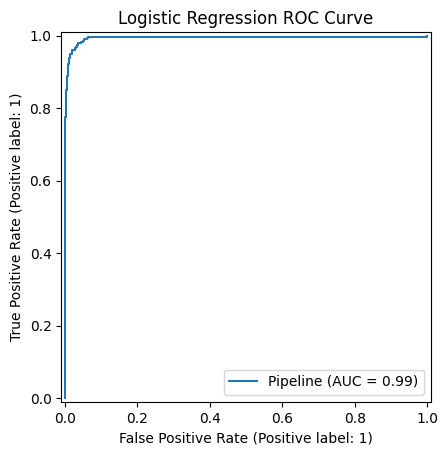

<Figure size 640x480 with 0 Axes>

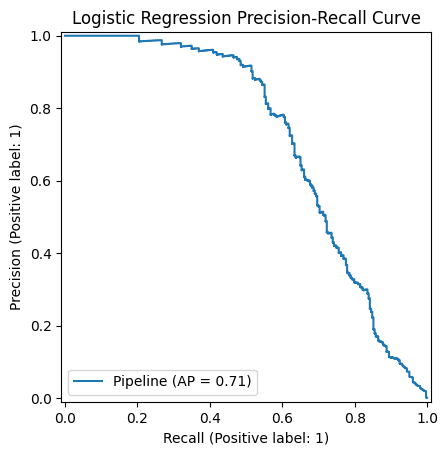

In [13]:
# =========================
# 2.2 Logistic Regression Baseline
# =========================
from sklearn.linear_model import LogisticRegression

lr = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=42))
])

lr.fit(X_train, y_train)

results = []
results.append(eval_binary_classifier("Logistic Regression", lr, X_test, y_test))
plot_roc_pr(lr, X_test, y_test, "Logistic Regression")


### Baseline Interpretation

Logistic Regression serves as the baseline model. It provides a useful point of comparison because it is simple, fast, and interpretable, but it may struggle to capture complex non-linear patterns in fraudulent transaction behavior.


Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best Tree Params: {'model__max_depth': 10, 'model__min_samples_leaf': 20}

=== Decision Tree (CV) ===
Accuracy: 0.9929
Precision: 0.1396
Recall: 0.9010
F1: 0.2418
ROC_AUC: 0.9498
PR_AUC: 0.7443


<Figure size 640x480 with 0 Axes>

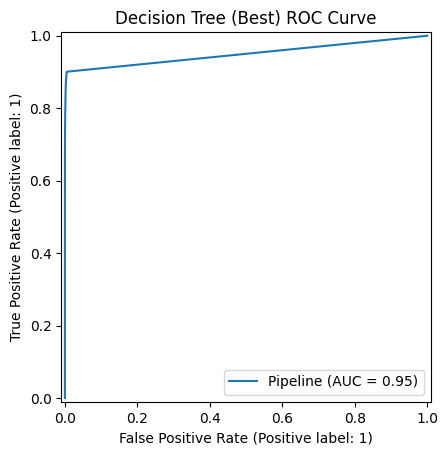

<Figure size 640x480 with 0 Axes>

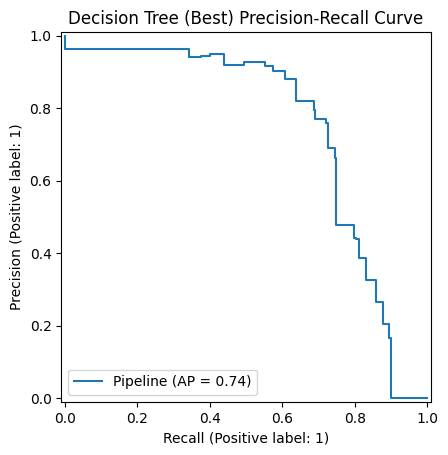

In [14]:
# =========================
# 2.3 Decision Tree + CV
# =========================
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

tree = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", DecisionTreeClassifier(class_weight="balanced", random_state=42))
])

param_grid_tree = {
    "model__max_depth": [3, 5, 7, 10],
    "model__min_samples_leaf": [5, 10, 20, 50]
}

gs_tree = GridSearchCV(
    tree,
    param_grid=param_grid_tree,
    scoring="f1",
    cv=5,
    n_jobs=-1,
    verbose=1
)

gs_tree.fit(X_train, y_train)
print("Best Tree Params:", gs_tree.best_params_)

best_tree = gs_tree.best_estimator_
results.append(eval_binary_classifier("Decision Tree (CV)", best_tree, X_test, y_test))
plot_roc_pr(best_tree, X_test, y_test, "Decision Tree (Best)")


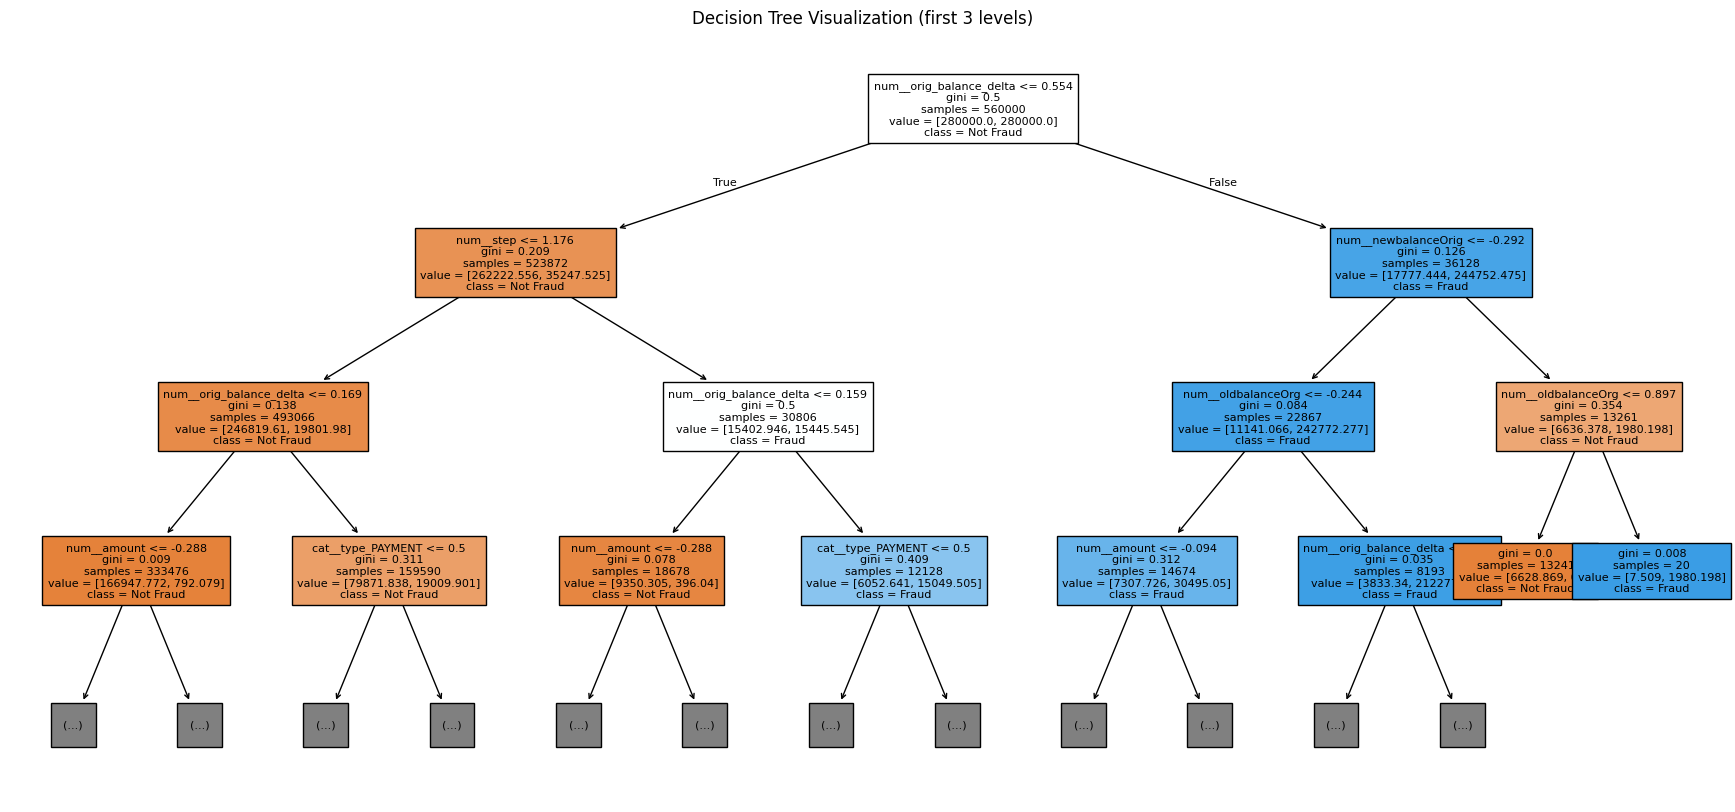

In [15]:

# Optional tree visualization (clipped depth for readability)
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

tree_clf = best_tree.named_steps["model"]
preprocessor_tree = best_tree.named_steps["preprocess"]

try:
    tree_feature_names = preprocessor_tree.get_feature_names_out()
except Exception:
    tree_feature_names = None

plt.figure(figsize=(22, 10))
plot_tree(
    tree_clf,
    max_depth=3,
    feature_names=tree_feature_names,
    class_names=["Not Fraud", "Fraud"],
    filled=True,
    fontsize=8
)
plt.title("Decision Tree Visualization (first 3 levels)")
plt.show()


### Decision Tree Interpretation

The decision tree improves interpretability by showing explicit splitting rules. However, while trees are easy to explain, a single tree can be unstable and may not match the predictive power of ensemble methods.


Fitting 5 folds for each of 6 candidates, totalling 30 fits
Best RF Params: {'model__max_depth': None, 'model__n_estimators': 100}

=== Random Forest (CV) ===
Accuracy: 0.9997
Precision: 0.9913
Recall: 0.7492
F1: 0.8534
ROC_AUC: 0.9832
PR_AUC: 0.8984


<Figure size 640x480 with 0 Axes>

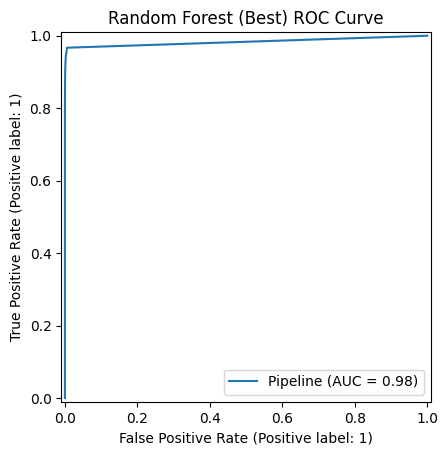

<Figure size 640x480 with 0 Axes>

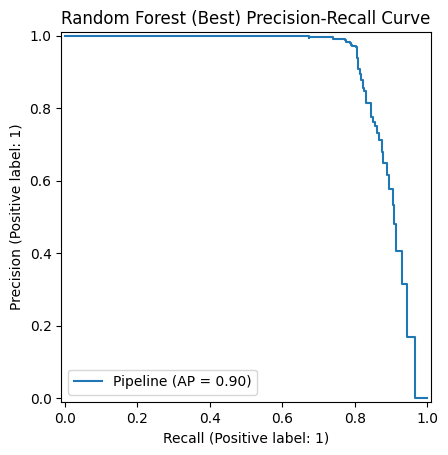

In [33]:
# =========================
# 2.4 Random Forest + CV
# =========================
from sklearn.ensemble import RandomForestClassifier

rf = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", RandomForestClassifier(
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ))
])

param_grid_rf = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [5, 8, None]
}

gs_rf = GridSearchCV(
    rf,
    param_grid=param_grid_rf,
    scoring="f1",
    cv=5,
    n_jobs=-1,
    verbose=1
)

gs_rf.fit(X_train, y_train)
print("Best RF Params:", gs_rf.best_params_)

best_rf = gs_rf.best_estimator_
results.append(eval_binary_classifier("Random Forest (CV)", best_rf, X_test, y_test))
plot_roc_pr(best_rf, X_test, y_test, "Random Forest (Best)")


### Random Forest Interpretation

Random Forest reduces the variance of a single decision tree by aggregating many trees. This often improves generalization and makes it a strong candidate for fraud detection, though the model becomes less interpretable than a single tree.


In [36]:

import sys
!{sys.executable} -m pip install -q xgboost shap


Fitting 5 folds for each of 8 candidates, totalling 40 fits
Best XGB Params: {'model__learning_rate': 0.1, 'model__max_depth': 5, 'model__n_estimators': 200}

=== XGBoost (CV) ===
Accuracy: 0.9997
Precision: 0.9630
Recall: 0.7723
F1: 0.8571
ROC_AUC: 0.9940
PR_AUC: 0.9075


<Figure size 640x480 with 0 Axes>

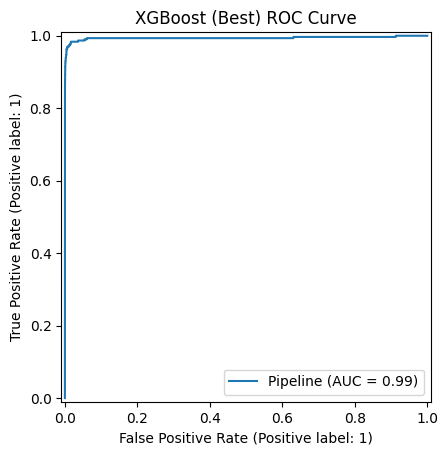

<Figure size 640x480 with 0 Axes>

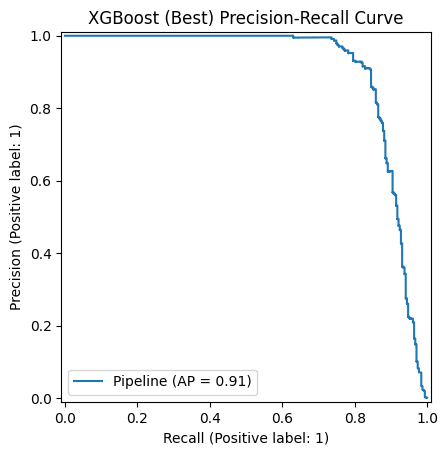

In [35]:
# =========================
# 2.5 XGBoost + CV
# =========================
from xgboost import XGBClassifier

xgb = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1,
        tree_method="hist"
    ))
])

param_grid_xgb = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [3, 5],
    "model__learning_rate": [0.05, 0.1]
}

gs_xgb = GridSearchCV(
    xgb,
    param_grid=param_grid_xgb,
    scoring="f1",
    cv=5,
    n_jobs=-1,
    verbose=1
)

gs_xgb.fit(X_train, y_train)
print("Best XGB Params:", gs_xgb.best_params_)

best_xgb = gs_xgb.best_estimator_
results.append(eval_binary_classifier("XGBoost (CV)", best_xgb, X_test, y_test))
plot_roc_pr(best_xgb, X_test, y_test, "XGBoost (Best)")


### Boosted Trees Interpretation

Gradient-boosted trees such as XGBoost typically perform very well on structured tabular datasets because they capture complex non-linear interactions and focus successive trees on correcting previous errors.


Epoch 1/8
219/219 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - auc: 0.4152 - loss: 0.1370 - val_auc: 0.8441 - val_loss: 0.0049
Epoch 2/8
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - auc: 0.8504 - loss: 0.0049 - val_auc: 0.9171 - val_loss: 0.0036
Epoch 3/8
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - auc: 0.9162 - loss: 0.0038 - val_auc: 0.9261 - val_loss: 0.0031
Epoch 4/8
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - auc: 0.9335 - loss: 0.0032 - val_auc: 0.9349 - val_loss: 0.0028
Epoch 5/8
219/219 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - auc: 0.9424 - loss: 0.0029 - val_auc: 0.9352 - val_loss: 0.0027
Epoch 6/8
219/219 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - auc: 0.9485 - loss: 0.0028 - val_auc: 0.9354 - val_loss: 0.0026
Epoch 7/8
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - auc: 0.9522 - loss: 0.0026 - val_auc: 0.9356 - val_loss: 0.0025
Epoch 8/8
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - auc: 0.9539 - loss: 0.0025 - val_auc: 0.9399 - val_loss: 0.0024


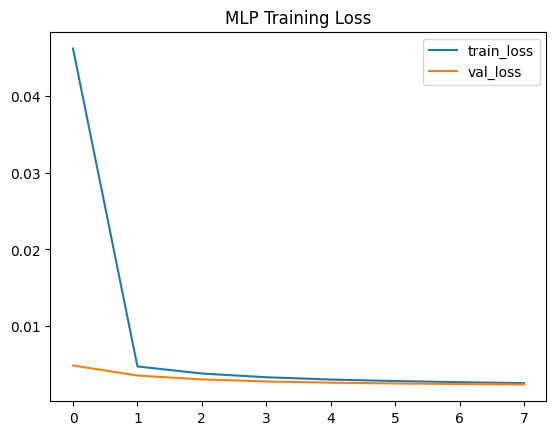

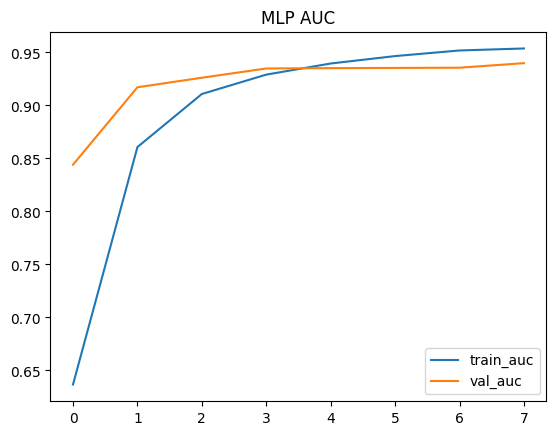


=== MLP (Keras) ===
Accuracy: 0.9994
Precision: 0.9819
Recall: 0.5380
F1: 0.6951
ROC_AUC: 0.9895
PR_AUC: 0.7647


<Figure size 640x480 with 0 Axes>

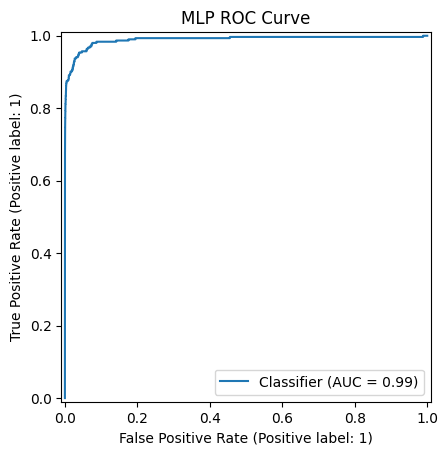

<Figure size 640x480 with 0 Axes>

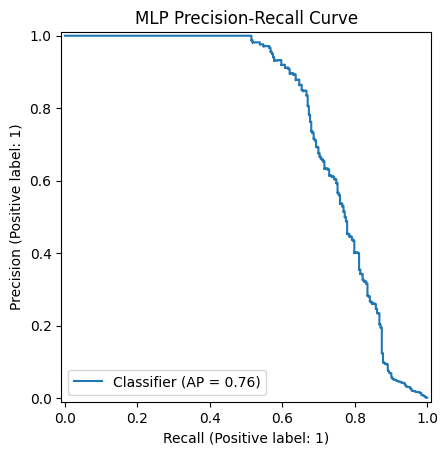

In [32]:
# =========================
# 2.6 Neural Net (MLP)
# =========================
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Fit the preprocess transformer on train only, then transform train/test
X_train_p = preprocess.fit_transform(X_train)
X_test_p = preprocess.transform(X_test)

# Keras wants dense arrays
# (If too big, we can use sparse->dense for a subset, but this usually works with our feature set)
if hasattr(X_train_p, "toarray"):
    X_train_nn = X_train_p.toarray()
    X_test_nn = X_test_p.toarray()
else:
    X_train_nn = X_train_p
    X_test_nn = X_test_p

tf.random.set_seed(42)

model = keras.Sequential([
    layers.Input(shape=(X_train_nn.shape[1],)),
    layers.Dense(128, activation="relu"),
    layers.Dense(128, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=[keras.metrics.AUC(name="auc")]
)

history = model.fit(
    X_train_nn, y_train.values,
    validation_split=0.2,
    epochs=8,
    batch_size=2048,
    verbose=1
)

# Plot training history
plt.figure()
plt.plot(history.history["loss"], label="train_loss")
plt.plot(history.history["val_loss"], label="val_loss")
plt.title("MLP Training Loss")
plt.legend()
plt.show()

plt.figure()
plt.plot(history.history["auc"], label="train_auc")
plt.plot(history.history["val_auc"], label="val_auc")
plt.title("MLP AUC")
plt.legend()
plt.show()

# Evaluate MLP on test
y_prob = model.predict(X_test_nn, verbose=0).ravel()
y_pred = (y_prob >= 0.5).astype(int)

mlp_metrics = {
    "Model": "MLP (Keras)",
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred, zero_division=0),
    "Recall": recall_score(y_test, y_pred, zero_division=0),
    "F1": f1_score(y_test, y_pred, zero_division=0),
    "ROC_AUC": roc_auc_score(y_test, y_prob),
    "PR_AUC": average_precision_score(y_test, y_prob)
}

print("\n=== MLP (Keras) ===")
for k, v in mlp_metrics.items():
    if k != "Model":
        print(f"{k}: {v:.4f}")

results.append(mlp_metrics)

# ROC/PR curves for MLP
plt.figure()
RocCurveDisplay.from_predictions(y_test, y_prob)
plt.title("MLP ROC Curve")
plt.show()

plt.figure()
PrecisionRecallDisplay.from_predictions(y_test, y_prob)
plt.title("MLP Precision-Recall Curve")
plt.show()


### Neural Network Interpretation

The MLP introduces a more flexible non-linear modeling approach. It can capture complex patterns, but it usually requires more training time and is less interpretable than tree-based models.


,Model,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,XGBoost,0.999675,0.962963,0.772277,0.857143,0.993997,0.907531
1,Random Forest,0.999675,0.991266,0.749175,0.853383,0.983197,0.898379
2,MLP,0.999404,0.981928,0.537954,0.695096,0.991057,0.771875
3,Decision Tree,0.992867,0.139642,0.900990,0.241807,0.949817,0.744276
4,Logistic Regression,0.961900,0.031479,0.980198,0.060998,0.993764,0.710239


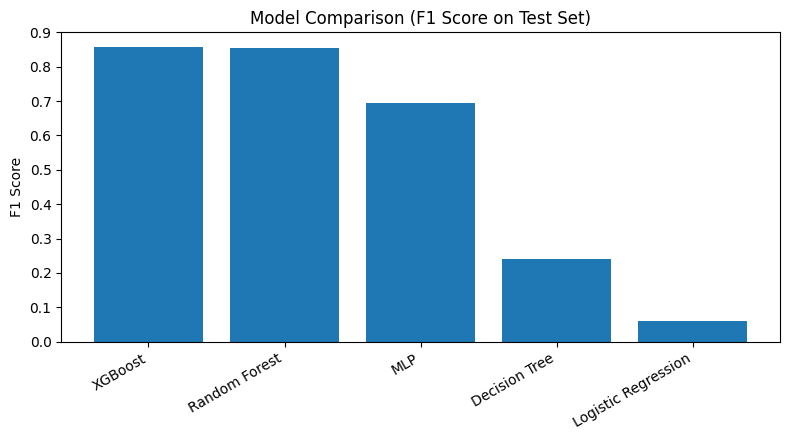

Best model by F1: XGBoost


In [31]:

# =========================
# 2.7 Model Comparison
# =========================
results_df = pd.DataFrame(results).copy()

# Standardize model labels for cleaner presentation
results_df["Model"] = results_df["Model"].replace({
    "Decision Tree (CV)": "Decision Tree",
    "Random Forest (CV)": "Random Forest",
    "XGBoost (CV)": "XGBoost",
    "MLP (Keras)": "MLP"
})

results_df = results_df.sort_values("F1", ascending=False).reset_index(drop=True)

display(results_df)

plt.figure(figsize=(8, 4.5))
plt.bar(results_df["Model"], results_df["F1"])
plt.title("Model Comparison (F1 Score on Test Set)")
plt.ylabel("F1 Score")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

print("Best model by F1:", results_df.loc[0, "Model"])


## Model Comparison

The comparison table above summarizes performance across all required models:
- Logistic Regression
- Decision Tree
- Random Forest
- XGBoost
- MLP

In this project, **tree-based ensemble models outperform simpler baselines**, which is expected for tabular fraud data with non-linear patterns and interaction effects. The strongest model offers the best balance between precision and recall, while simpler models remain useful as interpretable baselines.

From a business perspective, there is a practical trade-off:
- **Logistic Regression** is simple and explainable but may miss complex fraud patterns.
- **Decision Trees** are interpretable but can be unstable.
- **Random Forest and XGBoost** usually provide stronger predictive performance.
- **MLP** can model complex relationships but is harder to interpret and deploy than tree ensembles.

The best-performing model from this comparison is used as the primary model for explainability and deployment.


In [37]:
# =========================
# Save models for Streamlit
# =========================
import joblib
import os

os.makedirs("models", exist_ok=True)

joblib.dump(lr, "models/lr.pkl")
joblib.dump(best_tree, "models/tree.pkl")
joblib.dump(best_rf, "models/rf.pkl")
joblib.dump(best_xgb, "models/xgb.pkl")

# Save preprocessing separately for NN usage in Streamlit
joblib.dump(preprocess, "models/preprocess.pkl")

# Save Keras model
model.save("models/mlp.keras")

print("✅ Saved models to /models")


✅ Saved models to /models


## Part 3 — Explainability with SHAP

To interpret the best-performing tree-based model, SHAP (SHapley Additive exPlanations) is used. SHAP provides both **global explainability** and **local explainability**:

- **Summary plot:** shows which features matter most across many observations and whether they increase or decrease the model output
- **Bar plot:** ranks features by average importance
- **Waterfall plot:** explains one specific prediction in detail

This is especially important in fraud detection because analysts need to understand **why** a transaction is being flagged as suspicious.


In [38]:

import shap


In [30]:

# Prepare transformed training data for SHAP
X_train_processed = preprocess.transform(X_train)
if hasattr(X_train_processed, "toarray"):
    X_train_processed = X_train_processed.toarray()

# Explain the best tree-based model (XGBoost here)
tree_model = best_xgb.named_steps["model"]
explainer = shap.TreeExplainer(tree_model)

# Use a manageable sample for speed
sample_data = X_train_processed[:1000]
shap_values = explainer.shap_values(sample_data)
if isinstance(shap_values, list):
    shap_values = shap_values[1] if len(shap_values) > 1 else shap_values[0]

print("Processed training sample shape for SHAP:", sample_data.shape)
print("SHAP values shape:", np.array(shap_values).shape)

Processed training sample shape for SHAP: (1000, 13)
SHAP values shape: (1000, 13)


In [39]:

# Get feature names after preprocessing
def get_feature_names(preprocess, num_cols, cat_cols):
    num_features = list(num_cols)
    ohe = preprocess.named_transformers_["cat"].named_steps["onehot"]
    cat_features = ohe.get_feature_names_out(cat_cols).tolist()
    return num_features + cat_features

feature_names = get_feature_names(preprocess, num_cols, cat_cols)
print("Total processed feature names:", len(feature_names))
print("First 20 feature names:", feature_names[:20])


Total processed feature names: 13
First 20 feature names: ['step', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'orig_balance_delta', 'dest_balance_delta', 'type_CASH_IN', 'type_CASH_OUT', 'type_DEBIT', 'type_PAYMENT', 'type_TRANSFER']


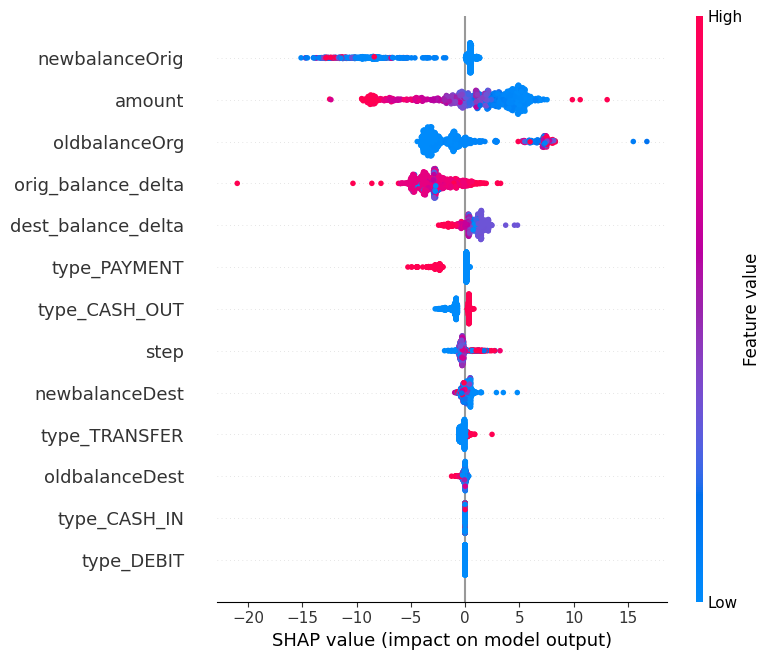

In [40]:

shap.summary_plot(shap_values, sample_data, feature_names=feature_names)


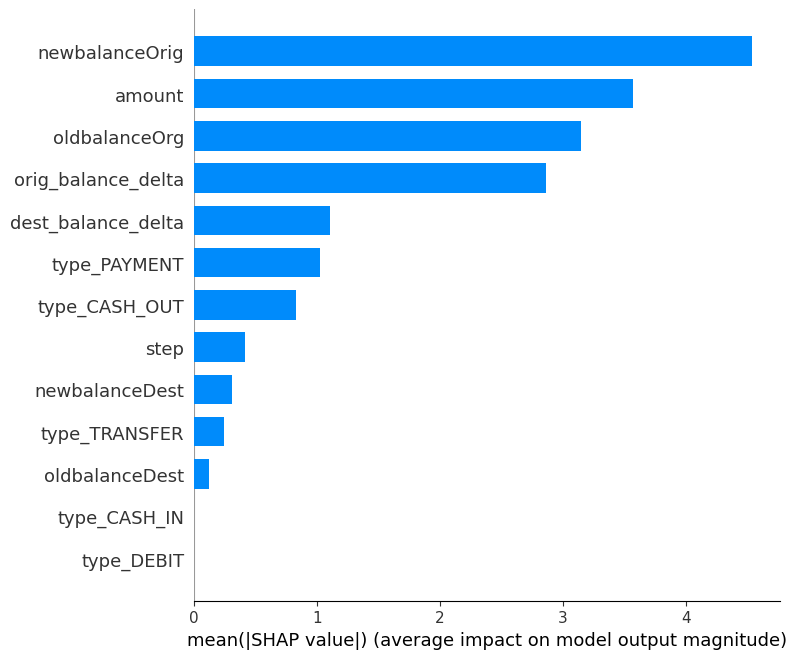

In [41]:

shap.summary_plot(shap_values, sample_data, feature_names=feature_names, plot_type="bar")


Chosen example index: 759
Predicted fraud probability for chosen example: 1.0


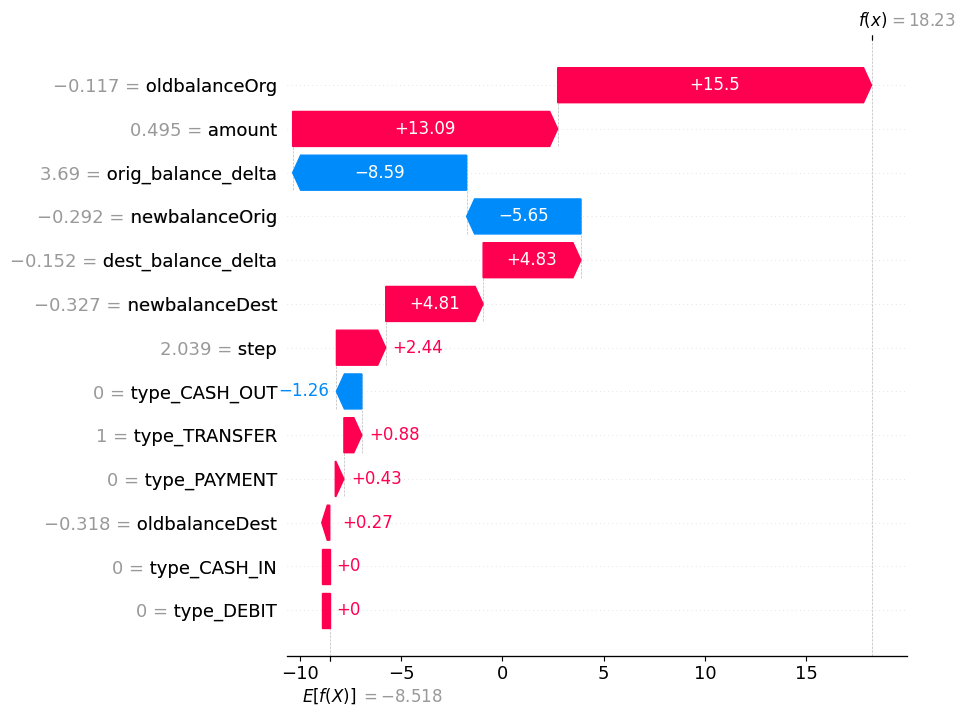

In [42]:

# SHAP waterfall for one high-risk transaction
import numpy as np
import matplotlib.pyplot as plt

probs = tree_model.predict_proba(sample_data)[:, 1]
idx = int(np.argmax(probs))
print("Chosen example index:", idx)
print("Predicted fraud probability for chosen example:", probs[idx])

expected_value = explainer.expected_value
if isinstance(expected_value, (list, np.ndarray)):
    expected_value = expected_value[1] if len(np.atleast_1d(expected_value)) > 1 else expected_value[0]

exp = shap.Explanation(
    values=shap_values[idx],
    base_values=expected_value,
    data=sample_data[idx],
    feature_names=feature_names
)

shap.plots.waterfall(exp, max_display=15)


In [43]:

## Save SHAP plots for Streamlit with final filenames
import os
import matplotlib.pyplot as plt

os.makedirs("models", exist_ok=True)

# Summary plot
plt.figure()
shap.summary_plot(
    shap_values,
    sample_data,
    feature_names=feature_names,
    show=False
)
plt.savefig("models/shap_summary.png", bbox_inches="tight", dpi=200)
plt.close()

# Bar plot
plt.figure()
shap.summary_plot(
    shap_values,
    sample_data,
    feature_names=feature_names,
    plot_type="bar",
    show=False
)
plt.savefig("models/shap_bar.png", bbox_inches="tight", dpi=200)
plt.close()

# Waterfall plot
expected_value = explainer.expected_value
if isinstance(expected_value, (list, np.ndarray)):
    expected_value = expected_value[1] if len(np.atleast_1d(expected_value)) > 1 else expected_value[0]

probs = tree_model.predict_proba(sample_data)[:, 1]
idx = int(np.argmax(probs))

exp = shap.Explanation(
    values=shap_values[idx],
    base_values=expected_value,
    data=sample_data[idx],
    feature_names=feature_names
)

plt.figure(figsize=(10, 6))
shap.plots.waterfall(exp, max_display=15, show=False)
plt.savefig("models/shap_waterfall.png", bbox_inches="tight", dpi=200)
plt.close()

print("✅ Saved final SHAP plots with real feature names:")
print("- models/shap_summary.png")
print("- models/shap_bar.png")
print("- models/shap_waterfall.png")


✅ Saved final SHAP plots with real feature names:
- models/shap_summary.png
- models/shap_bar.png
- models/shap_waterfall.png


## SHAP Interpretation

The SHAP outputs identify the features that most strongly influence fraud predictions. In fraud detection, balance-related variables and transaction characteristics often dominate because they capture unusual money movement patterns.

The **summary plot** shows both feature importance and the direction of impact across many observations, while the **bar plot** ranks variables by their average influence. The **waterfall plot** explains a single high-risk transaction by showing how individual features push the prediction toward or away from fraud.

These insights are valuable because they make the model more transparent for analysts and decision-makers who need confidence in automated fraud alerts.


In [44]:

# Optional: package saved models for easy download or transfer
import shutil
archive_path = shutil.make_archive("models_bundle", "zip", "models")
print(f"✅ Created archive: {archive_path}")


✅ Created archive: /content/models_bundle.zip


## Final Takeaways

This notebook demonstrates a complete end-to-end data science workflow for fraud detection:

1. **Descriptive analytics** revealed a highly imbalanced target and several features that differentiate fraud from legitimate transactions.
2. **Predictive analytics** compared multiple models, including Logistic Regression, Decision Tree, Random Forest, XGBoost, and MLP.
3. **Model comparison** identified the strongest-performing approach using F1 score and related classification metrics.
4. **SHAP explainability** made the best tree-based model more interpretable through summary, bar, and waterfall plots.
5. **Deployment preparation** saved the trained models and SHAP assets for use in the Streamlit app.

